<a href="https://colab.research.google.com/github/kudavmahesh88/CSL701-Roll_No_29_Machine-Learning-Lab/blob/main/Experiments/ML_Exp_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Mahesh Vishnu Kudav

Batch :CS2


Roll Number :CS29



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load dataset
df = pd.read_csv("data.csv")

# Display first five rows
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset Shape: (569, 33)

Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean    

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_wors

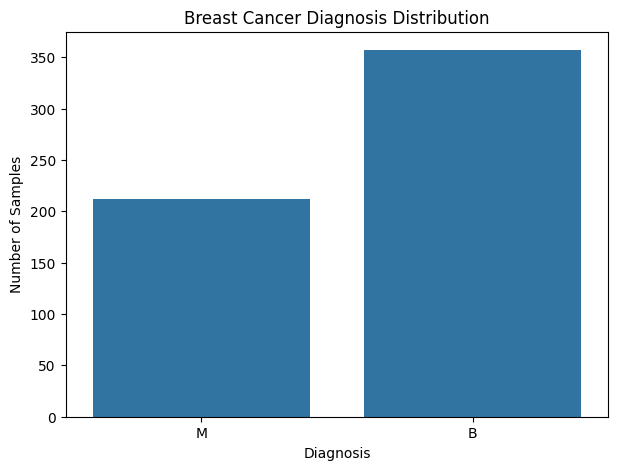

In [ ]:
# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check target class distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Breast Cancer Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()



# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# Create a copy of the dataset
data = df.copy()

# Drop unnecessary columns
data = data.drop(["id", "Unnamed: 32"], axis=1)

# Convert diagnosis into numerical values
data["diagnosis"] = data["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Separate features and target
X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Distribution:")
print(y.value_counts())


Feature Shape: (569, 30)
Target Shape: (569,)

Features:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Target Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
# Create StandardScaler
scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

# Check mean and standard deviation
print("Mean of scaled features:", np.mean(X_scaled, axis=0)[:5])
print("Standard deviation:", np.std(X_scaled, axis=0)[:5])


Scaled Data Shape: (569, 30)
Mean of scaled features: [-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16]
Standard deviation: [1. 1. 1. 1. 1.]


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
# Create PCA model with 2 principal components
pca = PCA(n_components=2)

# Transform the standardized data
X_pca = pca.fit_transform(X_scaled)

print("Original Data Shape:", X_scaled.shape)
print("PCA Data Shape:", X_pca.shape)


pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Diagnosis"] = y.values

pca_df.head()


Original Data Shape: (569, 30)
PCA Data Shape: (569, 2)


,PC1,PC2,Diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


Variance explained by PC1: 44.27%
Variance explained by PC2: 18.97%
Cumulative variance retained: 63.24%


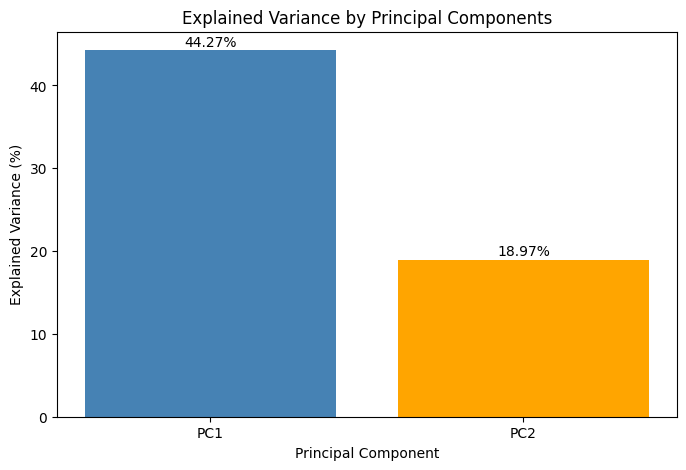

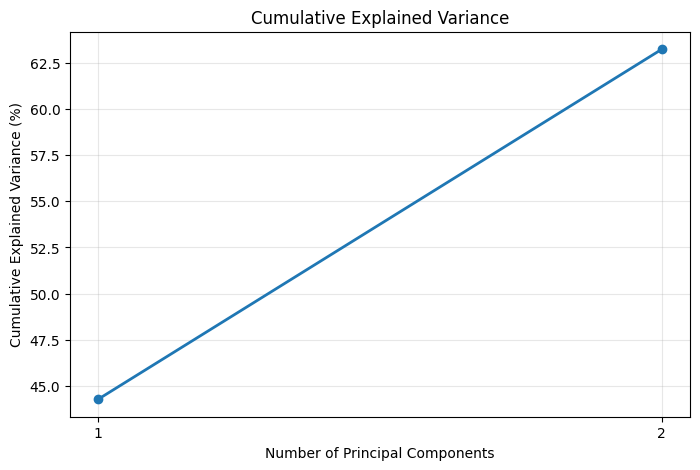

In [ ]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Variance explained by PC1: {:.2f}%".format(
    explained_variance[0] * 100
))

print("Variance explained by PC2: {:.2f}%".format(
    explained_variance[1] * 100
))

# Cumulative variance
cumulative_variance = np.sum(explained_variance)

print("Cumulative variance retained: {:.2f}%".format(
    cumulative_variance * 100
))



plt.figure(figsize=(8, 5))

components = ["PC1", "PC2"]

plt.bar(
    components,
    explained_variance * 100,
    color=["steelblue", "orange"]
)

plt.ylabel("Explained Variance (%)")
plt.xlabel("Principal Component")
plt.title("Explained Variance by Principal Components")

for i, value in enumerate(explained_variance * 100):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()



plt.figure(figsize=(8, 5))

cumulative = np.cumsum(explained_variance)

plt.plot(
    range(1, len(cumulative) + 1),
    cumulative * 100,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.xticks([1, 2])

plt.grid(alpha=0.3)
plt.show()




# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

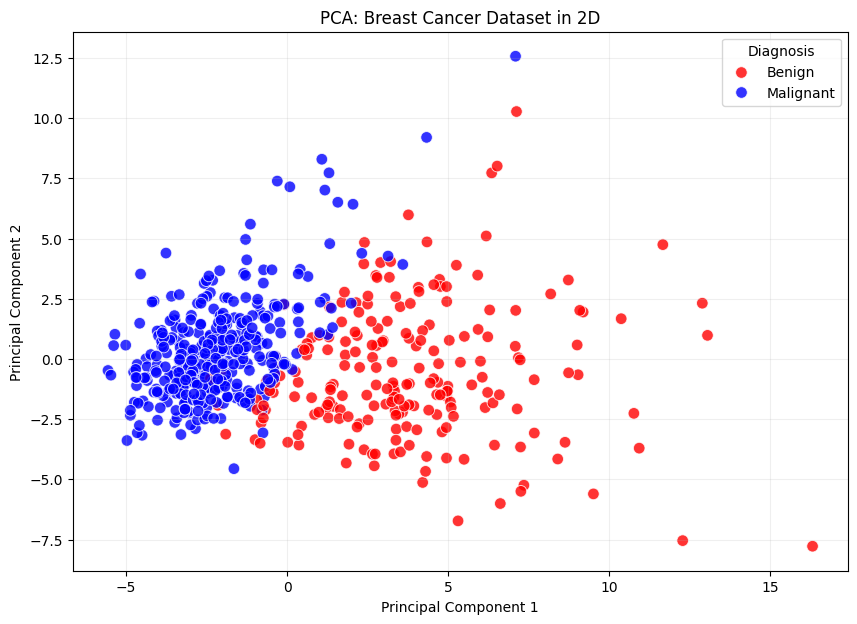

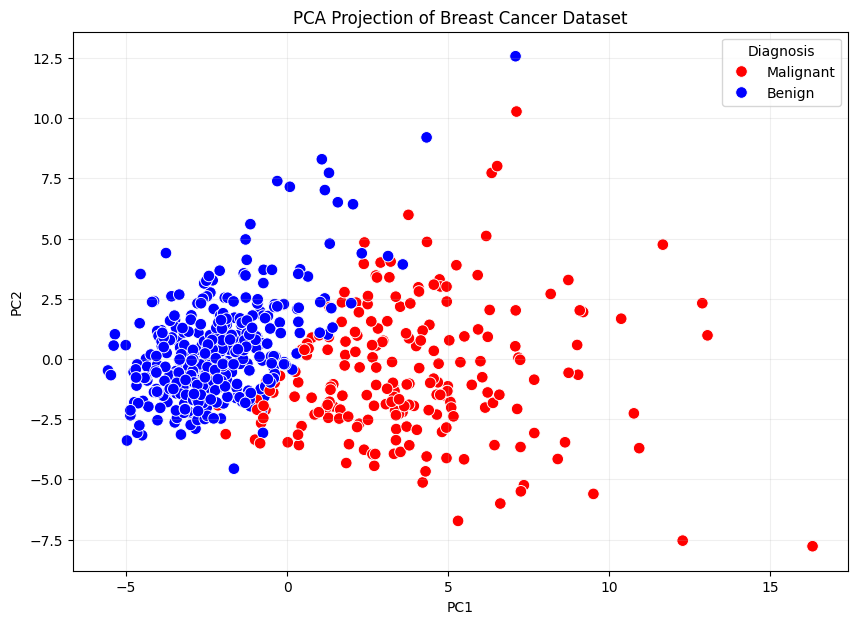

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette={
        0: "blue",
        1: "red"
    },
    s=70,
    alpha=0.8
)

plt.title("PCA: Breast Cancer Dataset in 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Diagnosis",
    labels=["Benign", "Malignant"]
)

plt.grid(alpha=0.2)
plt.show()


pca_plot_df = pca_df.copy()

pca_plot_df["Diagnosis"] = pca_plot_df["Diagnosis"].map({
    0: "Benign",
    1: "Malignant"
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette={
        "Benign": "blue",
        "Malignant": "red"
    },
    s=70
)

plt.title("PCA Projection of Breast Cancer Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.show()



# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

Logistic Regression Accuracy using 30 features:
96.49%


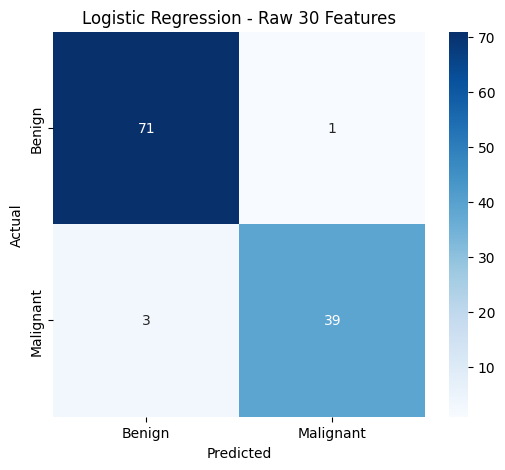

Classification Report - Raw 30 Features
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
# Split original scaled dataset
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logistic_raw = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Train model
logistic_raw.fit(
    X_train_raw,
    y_train_raw
)

# Predictions
y_pred_raw = logistic_raw.predict(X_test_raw)

# Accuracy
raw_accuracy = accuracy_score(
    y_test_raw,
    y_pred_raw
)

print("Logistic Regression Accuracy using 30 features:")
print("{:.2f}%".format(raw_accuracy * 100))



cm_raw = confusion_matrix(
    y_test_raw,
    y_pred_raw
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_raw,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Logistic Regression - Raw 30 Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


print("Classification Report - Raw 30 Features")
print(
    classification_report(
        y_test_raw,
        y_pred_raw,
        target_names=["Benign", "Malignant"]
    )
)



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

Logistic Regression Accuracy using 2 PCA features:
93.86%


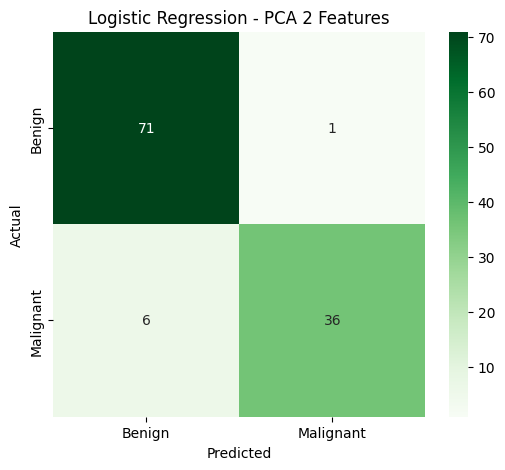

Classification Report - PCA 2 Features
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [ ]:
# Split PCA-transformed data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logistic_pca = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Train model
logistic_pca.fit(
    X_train_pca,
    y_train_pca
)

# Predictions
y_pred_pca = logistic_pca.predict(X_test_pca)

# Accuracy
pca_accuracy = accuracy_score(
    y_test_pca,
    y_pred_pca
)

print("Logistic Regression Accuracy using 2 PCA features:")
print("{:.2f}%".format(pca_accuracy * 100))



cm_pca = confusion_matrix(
    y_test_pca,
    y_pred_pca
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Logistic Regression - PCA 2 Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



print("Classification Report - PCA 2 Features")

print(
    classification_report(
        y_test_pca,
        y_pred_pca,
        target_names=["Benign", "Malignant"]
    )
)



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



Performance Comparison
Logistic Regression - 30 Features: 96.49%
Logistic Regression - 2 PCA Features: 93.86%


,Model,Accuracy,Accuracy (%)
0,Logistic Regression - 30 Features,0.964912,96.491228
1,Logistic Regression - 2 PCA Features,0.938596,93.859649


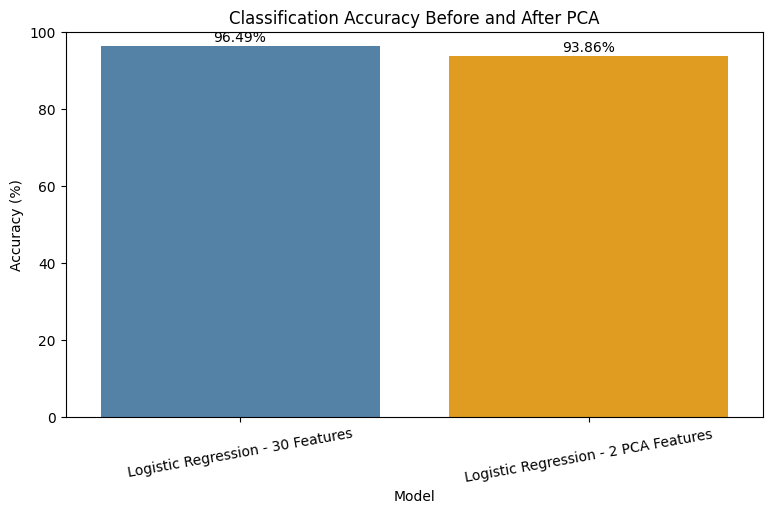

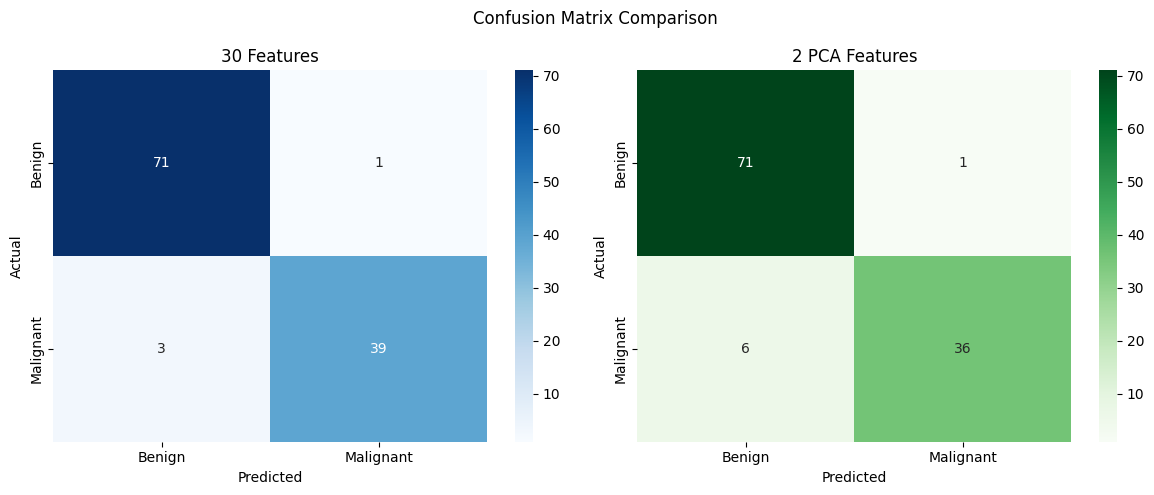

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression - 30 Features,96.49,97.5,92.86,95.12
1,Logistic Regression - 2 PCA Features,93.86,97.3,85.71,91.14


In [ ]:
print("Performance Comparison")
print("=" * 50)

print(
    "Logistic Regression - 30 Features: {:.2f}%".format(
        raw_accuracy * 100
    )
)

print(
    "Logistic Regression - 2 PCA Features: {:.2f}%".format(
        pca_accuracy * 100
    )
)


comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - 30 Features",
        "Logistic Regression - 2 PCA Features"
    ],
    "Accuracy": [
        raw_accuracy,
        pca_accuracy
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

display(comparison)



plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy (%)",
    hue="Model",
    palette=["steelblue", "orange"],
    legend=False
)

plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Classification Accuracy Before and After PCA")

plt.xticks(rotation=10)

for i, value in enumerate(comparison["Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()



fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Raw features
sns.heatmap(
    cm_raw,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[0]
)

axes[0].set_title("30 Features")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# PCA features
sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[1]
)

axes[1].set_title("2 PCA Features")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison")
plt.tight_layout()
plt.show()



from sklearn.metrics import precision_score, recall_score, f1_score

performance = pd.DataFrame({
    "Model": [
        "Logistic Regression - 30 Features",
        "Logistic Regression - 2 PCA Features"
    ],
    "Accuracy": [
        accuracy_score(y_test_raw, y_pred_raw),
        accuracy_score(y_test_pca, y_pred_pca)
    ],
    "Precision": [
        precision_score(y_test_raw, y_pred_raw),
        precision_score(y_test_pca, y_pred_pca)
    ],
    "Recall": [
        recall_score(y_test_raw, y_pred_raw),
        recall_score(y_test_pca, y_pred_pca)
    ],
    "F1-Score": [
        f1_score(y_test_raw, y_pred_raw),
        f1_score(y_test_pca, y_pred_pca)
    ]
})

performance[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]] *= 100

display(performance.round(2))



# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.